<a href="https://colab.research.google.com/github/aaronhowellai/machine-learning-projects/blob/aaronhowellai-patch-1/large%20language%20models/Transcribing%20Text%20Documents%20with%20Claude%204%20Opus%20API.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Transcribing Text Documents 🖹 with the Claude Opus API** ✨

### **Why Transcribe Text with an LLM API?**
* Perfectly formatted text may not always be gathered when collecting crucial data to feed into or train a model.
  * Unstructured data embedded in images still has a place in data collection too, and **can be extracted efficiently by multimodal models such as Claude 4 Opus**, and automatically formatted in the intended way at scale, saving the need for manual labour on the same task.

### **Notebook Feats**
* Implementing guidance from anthropic's [GitHub Multimodal Cookbook on How to Transcribe Text](https://github.com/anthropics/anthropic-cookbook/blob/main/multimodal/how_to_transcribe_text.ipynb), in this notebook, I use the Claude 3 Opus API to:
  * **Encode images for API input** – wrote a helper function that reads an image file and base64‑encodes it so it can be sent as multimodal input to Claude.
  * **Target transcription with prompts** – instead of doing generic [Optical Character Recognition](https://en.wikipedia.org/wiki/Optical_character_recognition), leveraged Claude 3’s advanced reasoning to transcribe only the desired parts of a document (such as the code in a screenshot), using precise prompts.

    * **Optical Character Recognition** or optical character reader (OCR) is the electronic or mechanical conversion of images of typed, handwritten or printed text into machine-encoded text

  * **Convert unstructured visuals into structured text** – used Claude’s vision capabilities to turn unstructured text in images/PDFs into structured responses, highlighting the model’s flexibility and superior control over what gets transcribed.

In [ ]:
# install packages
!pip install anthropic

In [ ]:
import anthropic
import base64
from google.colab import userdata
from IPython.display import Markdown
import requests
import pathlib
from PIL import Image
MODEL_ID = "claude-opus-4-20250514"

# test api
client = anthropic.Anthropic(
    api_key = userdata.get('ANTHROPIC_API_KEY')
)
message = client.messages.create(
    model=MODEL_ID,
    max_tokens=1024,
    messages=[
        {"role":"user", "content":"Hello, Claude 4..."}
    ]
)
print(message.content)

[TextBlock(citations=None, text="Hello! I'm Claude, an AI assistant created by Anthropic. How can I help you today?", type='text')]


In [ ]:
# function for reading an image and encoding it
def get_base64_encoded_image(image_path):
  with open(image_path, 'rb') as image_file:
    binary_data = image_file.read()
    base_64_encoded_data = base64.b64encode(binary_data)
    base64_string = base_64_encoded_data.decode('utf-8')
  return base64_string

## **Transcribing Typed Text**
* Unlike traditional OCR systems, you can specify exactly what you want to transcribe in a document.

Image already downloaded locally.


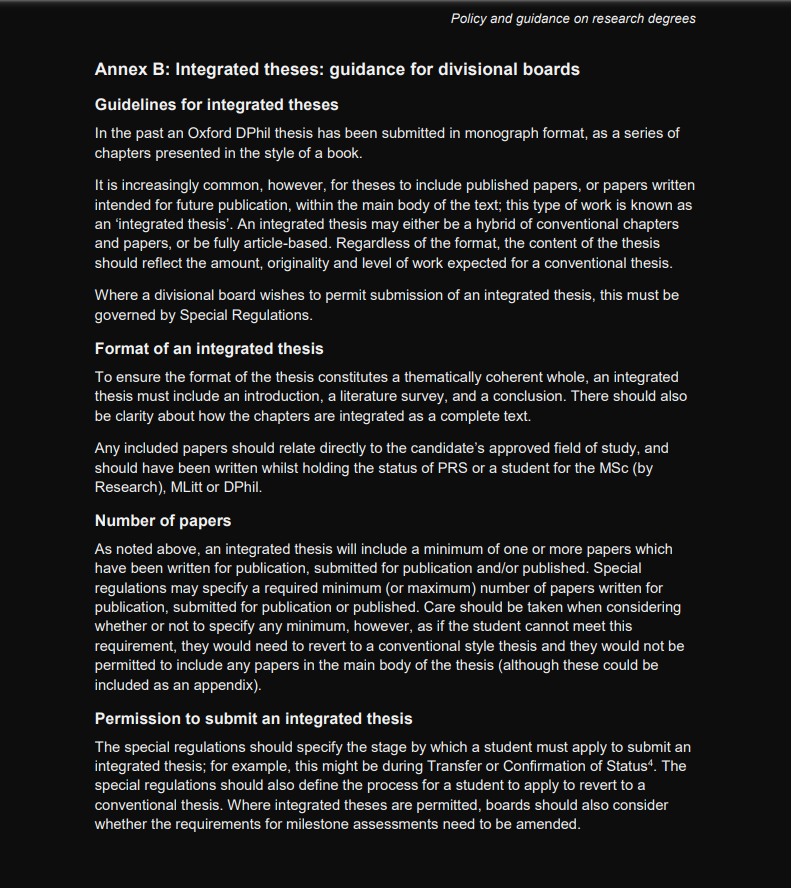

In [ ]:
# file info
image_url = "https://raw.githubusercontent.com/aaronhowellai/machine-learning-projects/main/resources/Oxford%20Policy%20and%20Guidance%20on%20Research%20Degrees.png"
filename = "Oxford Policy and Guidance on Research Degrees.png"

def display_image(image_url, filename, local_path=None):
  # step 1: check if the file already exists
  if Path(filename).exists():
    local_path = filename
    print("Image already downloaded locally.")

  else:
    try:
      # step 2: try colab path
      from google.colab import drive
      colab_path = f"/content/{filename}"
      r = requests.get(image_url)
      with open(colab_path, 'wb') as f:
        f.write(r.content)
      print(f"Downloaded to {colab_path}")
    except Exception as colab_error:
      try:
        # step 3: fallback to desktop
        desktop_path = Path.home() / "Desktop" / filename
        r = requests.get(image_url)
        with open(desktop_path, 'wb') as f:
          f.write(r.content)
        local_path = str(desktop_path)
        print(f"Downloaded to Desktop: {desktop_path}")
      except Exception as fallback_error:
        print("Failed to download image in both locations.")

  # step 4: auto display image
  if local_path:
    display(Image(filename=local_path))
  elif colab_path:
    display(Image(filename=colab_path))

display_image(image_url, filename)

In [ ]:
# for desktop version, use: "get_base64_encoded_image(desktop_path)}},"

In [ ]:
# this is the colab version
message_list = [
    {
        "role":"user",
        "content": [
            {"type": "image", "source": {"type": "base64", "media_type":"image/png", "data": get_base64_encoded_image(image_path="/content/Oxford Policy and Guidance on Research Degrees.png")}},
            {"type": "text", "text": "Transcribe the 'Number of papers' section in the image. Only output that section."}
        ]
    }
]

response = client.messages.create(
    model=MODEL_ID,
    max_tokens=3000,
    messages = message_list
)
response_text = response.content[0].text
display(Markdown(f"""\
{response_text}
"""))

Number of papers

As noted above, an integrated thesis will include a minimum of one or more papers which have been written for publication, submitted for publication and/or published. Special regulations may specify a required minimum (or maximum) number of papers written for publication, submitted for publication or published. Care should be taken when considering whether or not to specify any minimum, however, as if the student cannot meet this requirement, they would need to revert to a conventional style thesis and they would not be permitted to include any papers in the main body of the thesis (although these could be included as an appendix).


## **Transcribing Handwritten Text**
* [Link to image](https://github.com/aaronhowellai/machine-learning-projects/blob/main/resources/handwritten%20note.jpg)
* **Note:** *Interestingly, while most of the transcription is correct, not all of it is. Humans, using context awareness, can probably distinguish the errors easily. Therefore, exercise caution when using this as an all-powerful system in business due to the margin of error.*

Image already downloaded locally.


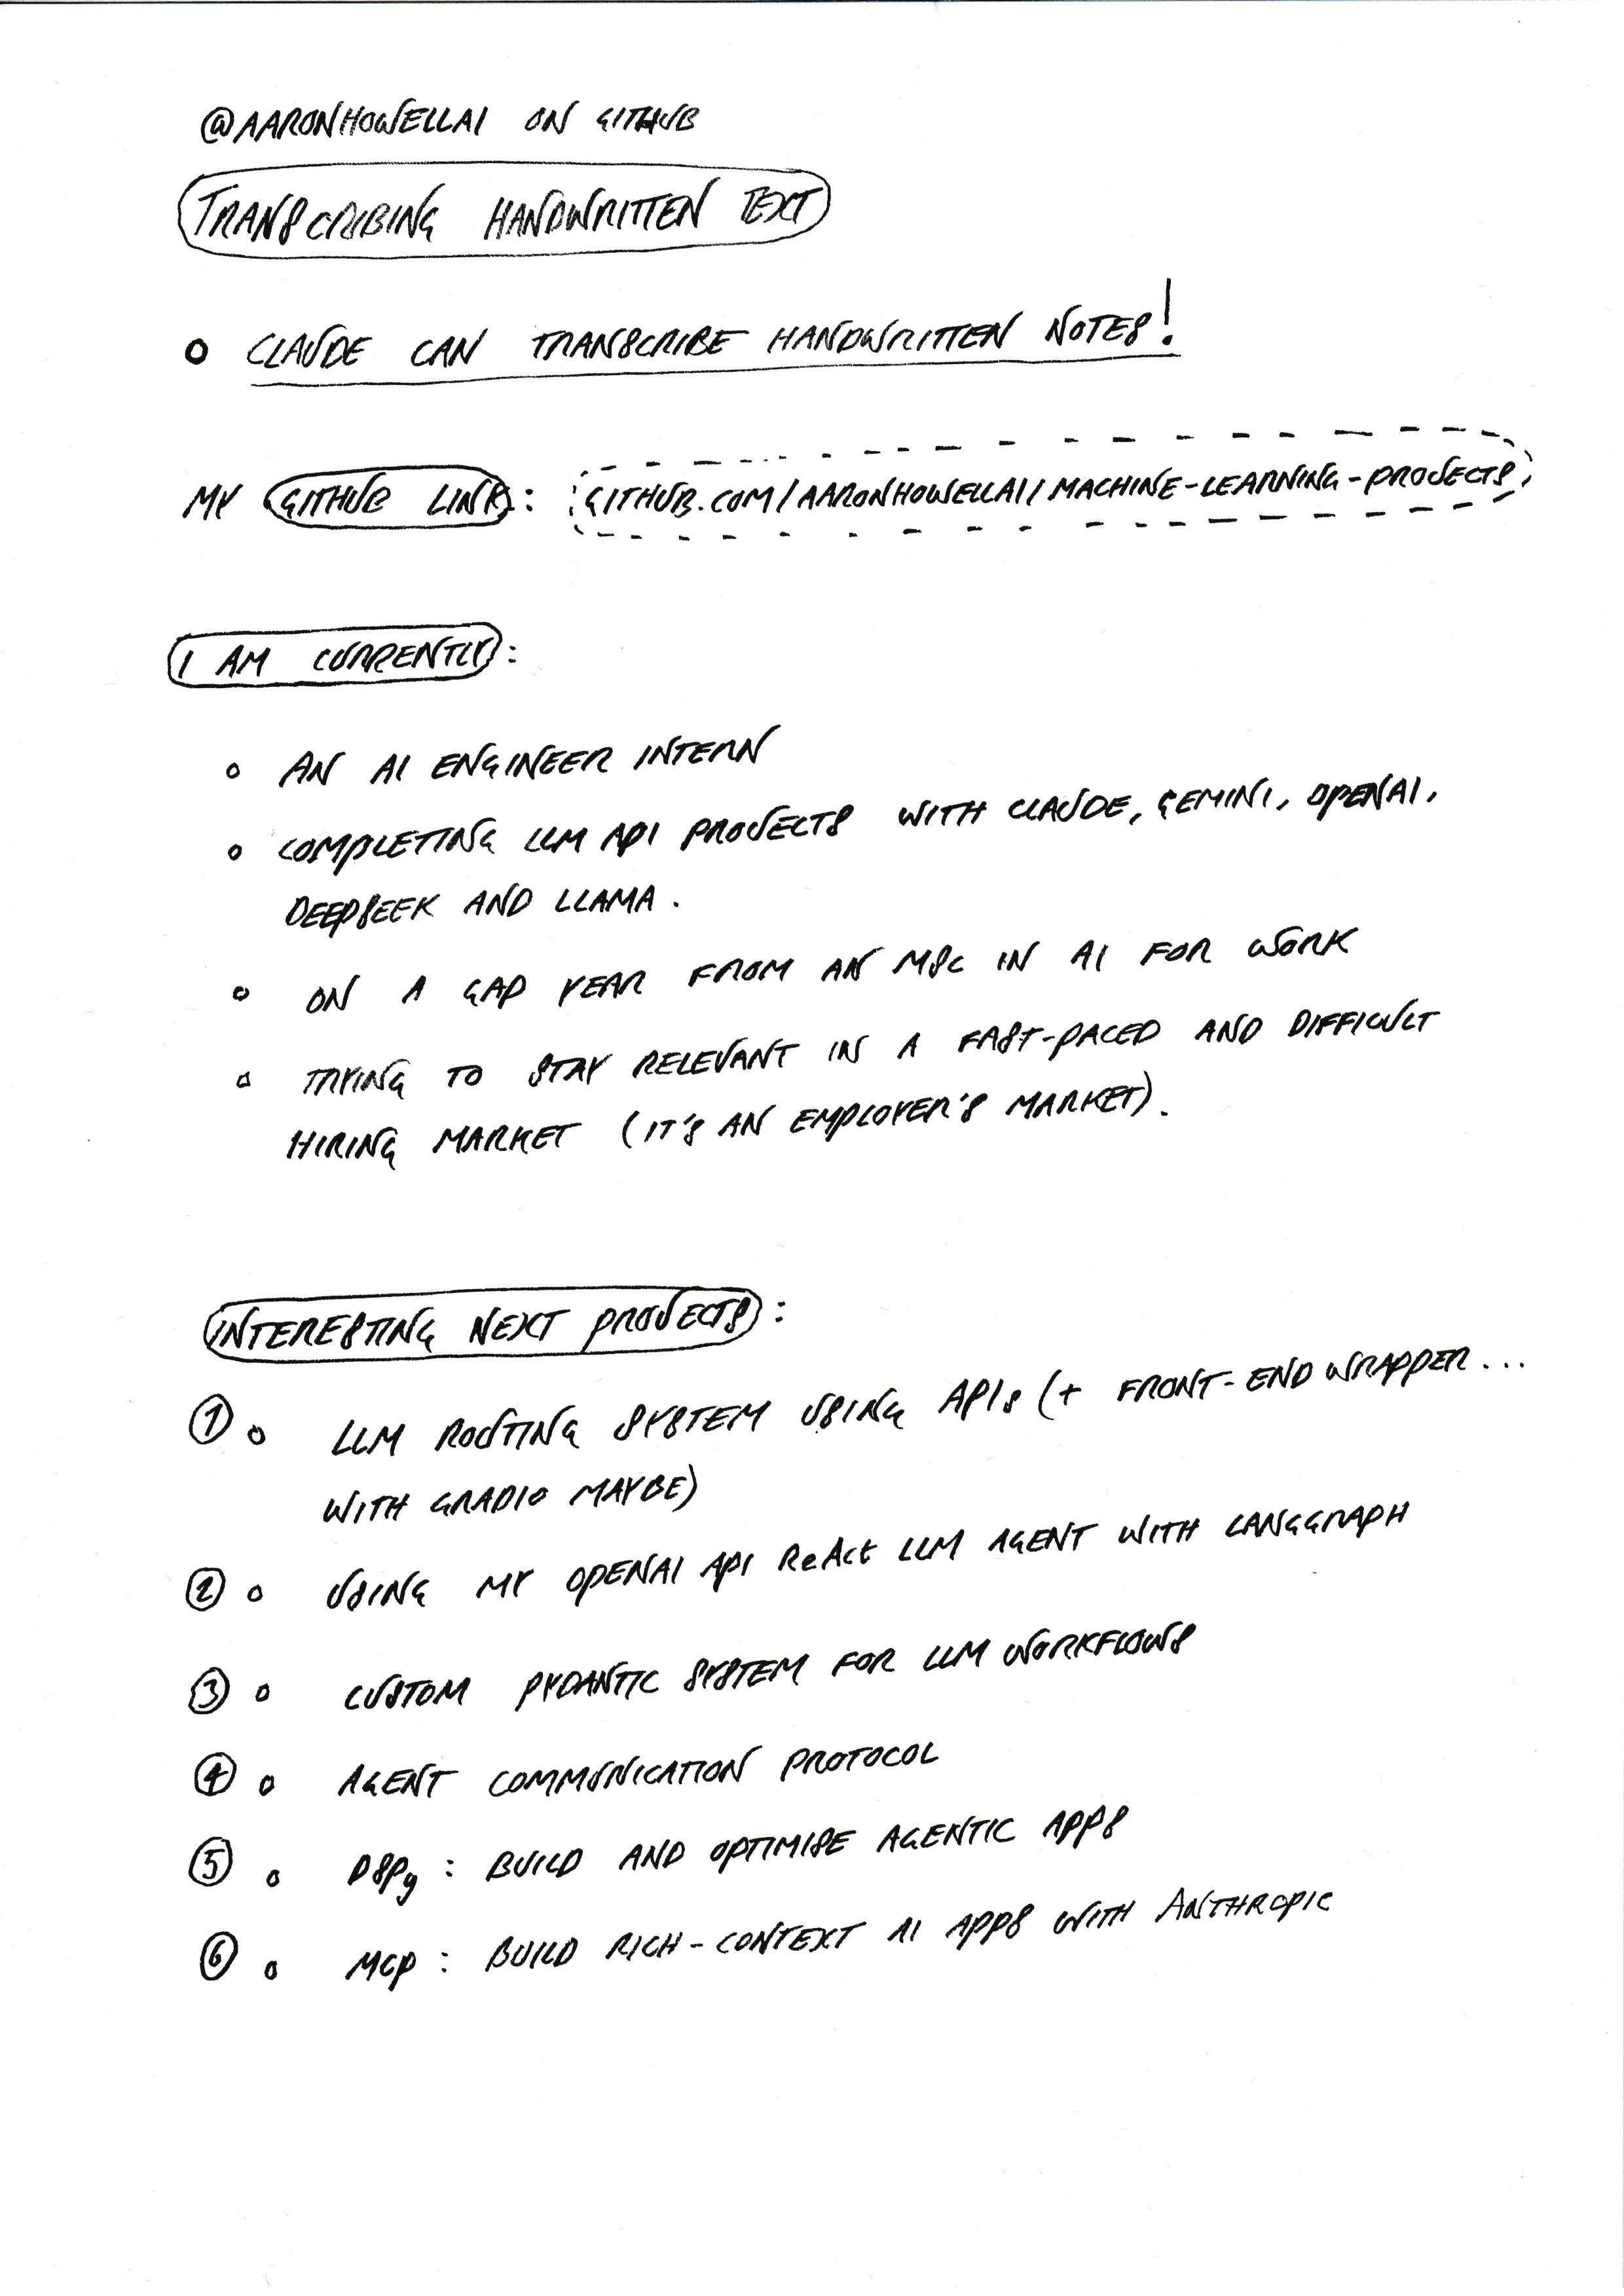

In [ ]:
# file info
image_url = "https://raw.githubusercontent.com/aaronhowellai/machine-learning-projects/main/resources/handwritten%20note.jpg"
filename = "handwritten note.jpg"

display_image(image_url, filename)

In [ ]:
# for desktop version, use: "get_base64_encoded_image(desktop_path)}},"

In [ ]:
# this is the colab version
message_list = [
    {
        "role":"user",
        "content": [
            {"type": "image", "source": {"type": "base64", "media_type":"image/jpeg", "data": get_base64_encoded_image(image_path="/content/handwritten note.jpg")}},
            {"type": "text", "text": "Transcribe this text. Output text only and use formatting such as '- bullet point' or '-------- (separator)' if necessary."}
        ]
    }
]

response = client.messages.create(
    model=MODEL_ID,
    max_tokens=3000,
    messages = message_list
)
print(response.content[0].text)

@AARONHOELELLA1 ON GITHUB

TRANSCRIBING HANDWRITTEN TEXT

o CLAUDE CAN TRANSCRIBE HANDWRITTEN NOTES!

MY GITHUB LINK: <GITHUB.COM/AARONHOELELLA1/MACHINE-LEARNING-PROJECTS>

I AM CURRENTLY:

o AN AI ENGINEER INTERN
o COMPLETING LLM API PROJECTS WITH CLAUDE, GEMINI, OPENAI, DEEPSEEK AND LLAMA.
o ON A GAP YEAR FROM AN MSC IN AI FOR CSUK
o TRYING TO STAY RELEVANT IN A FAST-PACED AND DIFFICULT HIRING MARKET (IT'S AN EXPLORERS MARKET).

INTERESTING NEXT PROJECT:

1) o LLM ROUTING SYSTEM USING APIs (+ FRONT-END WRAPPER... WITH GRADIO MAYBE)

2) o USING MY OPENAI API REACT LLM AGENT WITH LANGRAPH

3) o CUSTOM PHONETIC SYSTEM FOR LLM WORKFLOWS?

4) o AGENT COMMUNICATION PROTOCOL

5) o DVF3: BUILD AND OPTIMISE AGENTIC APPS

6) o MCP: BUILD RICH-CONTEXT AI APPS WITH ANTHROPIC


In [ ]:
# not all correct but close

## **Transcribing Forms**
**Example Used:** Mixed with handwritten and typed text — downloaded from the web.
* [Link](https://raw.githubusercontent.com/aaronhowellai/machine-learning-projects/main/resources/handwritten%20form.jpg)

**Note:**
* *Like above, while most of it is correct, not all of it is. Humans, using context awareness, can likely distinguish the errors, so caution is advised when using this as an all‑powerful system in business due to the margin of error.*
* There may be a case for improving performance by combining OCR, NLTK traditional and multimodal LLM methods, fine‑tuned as a bespoke solution.

Image already downloaded locally.


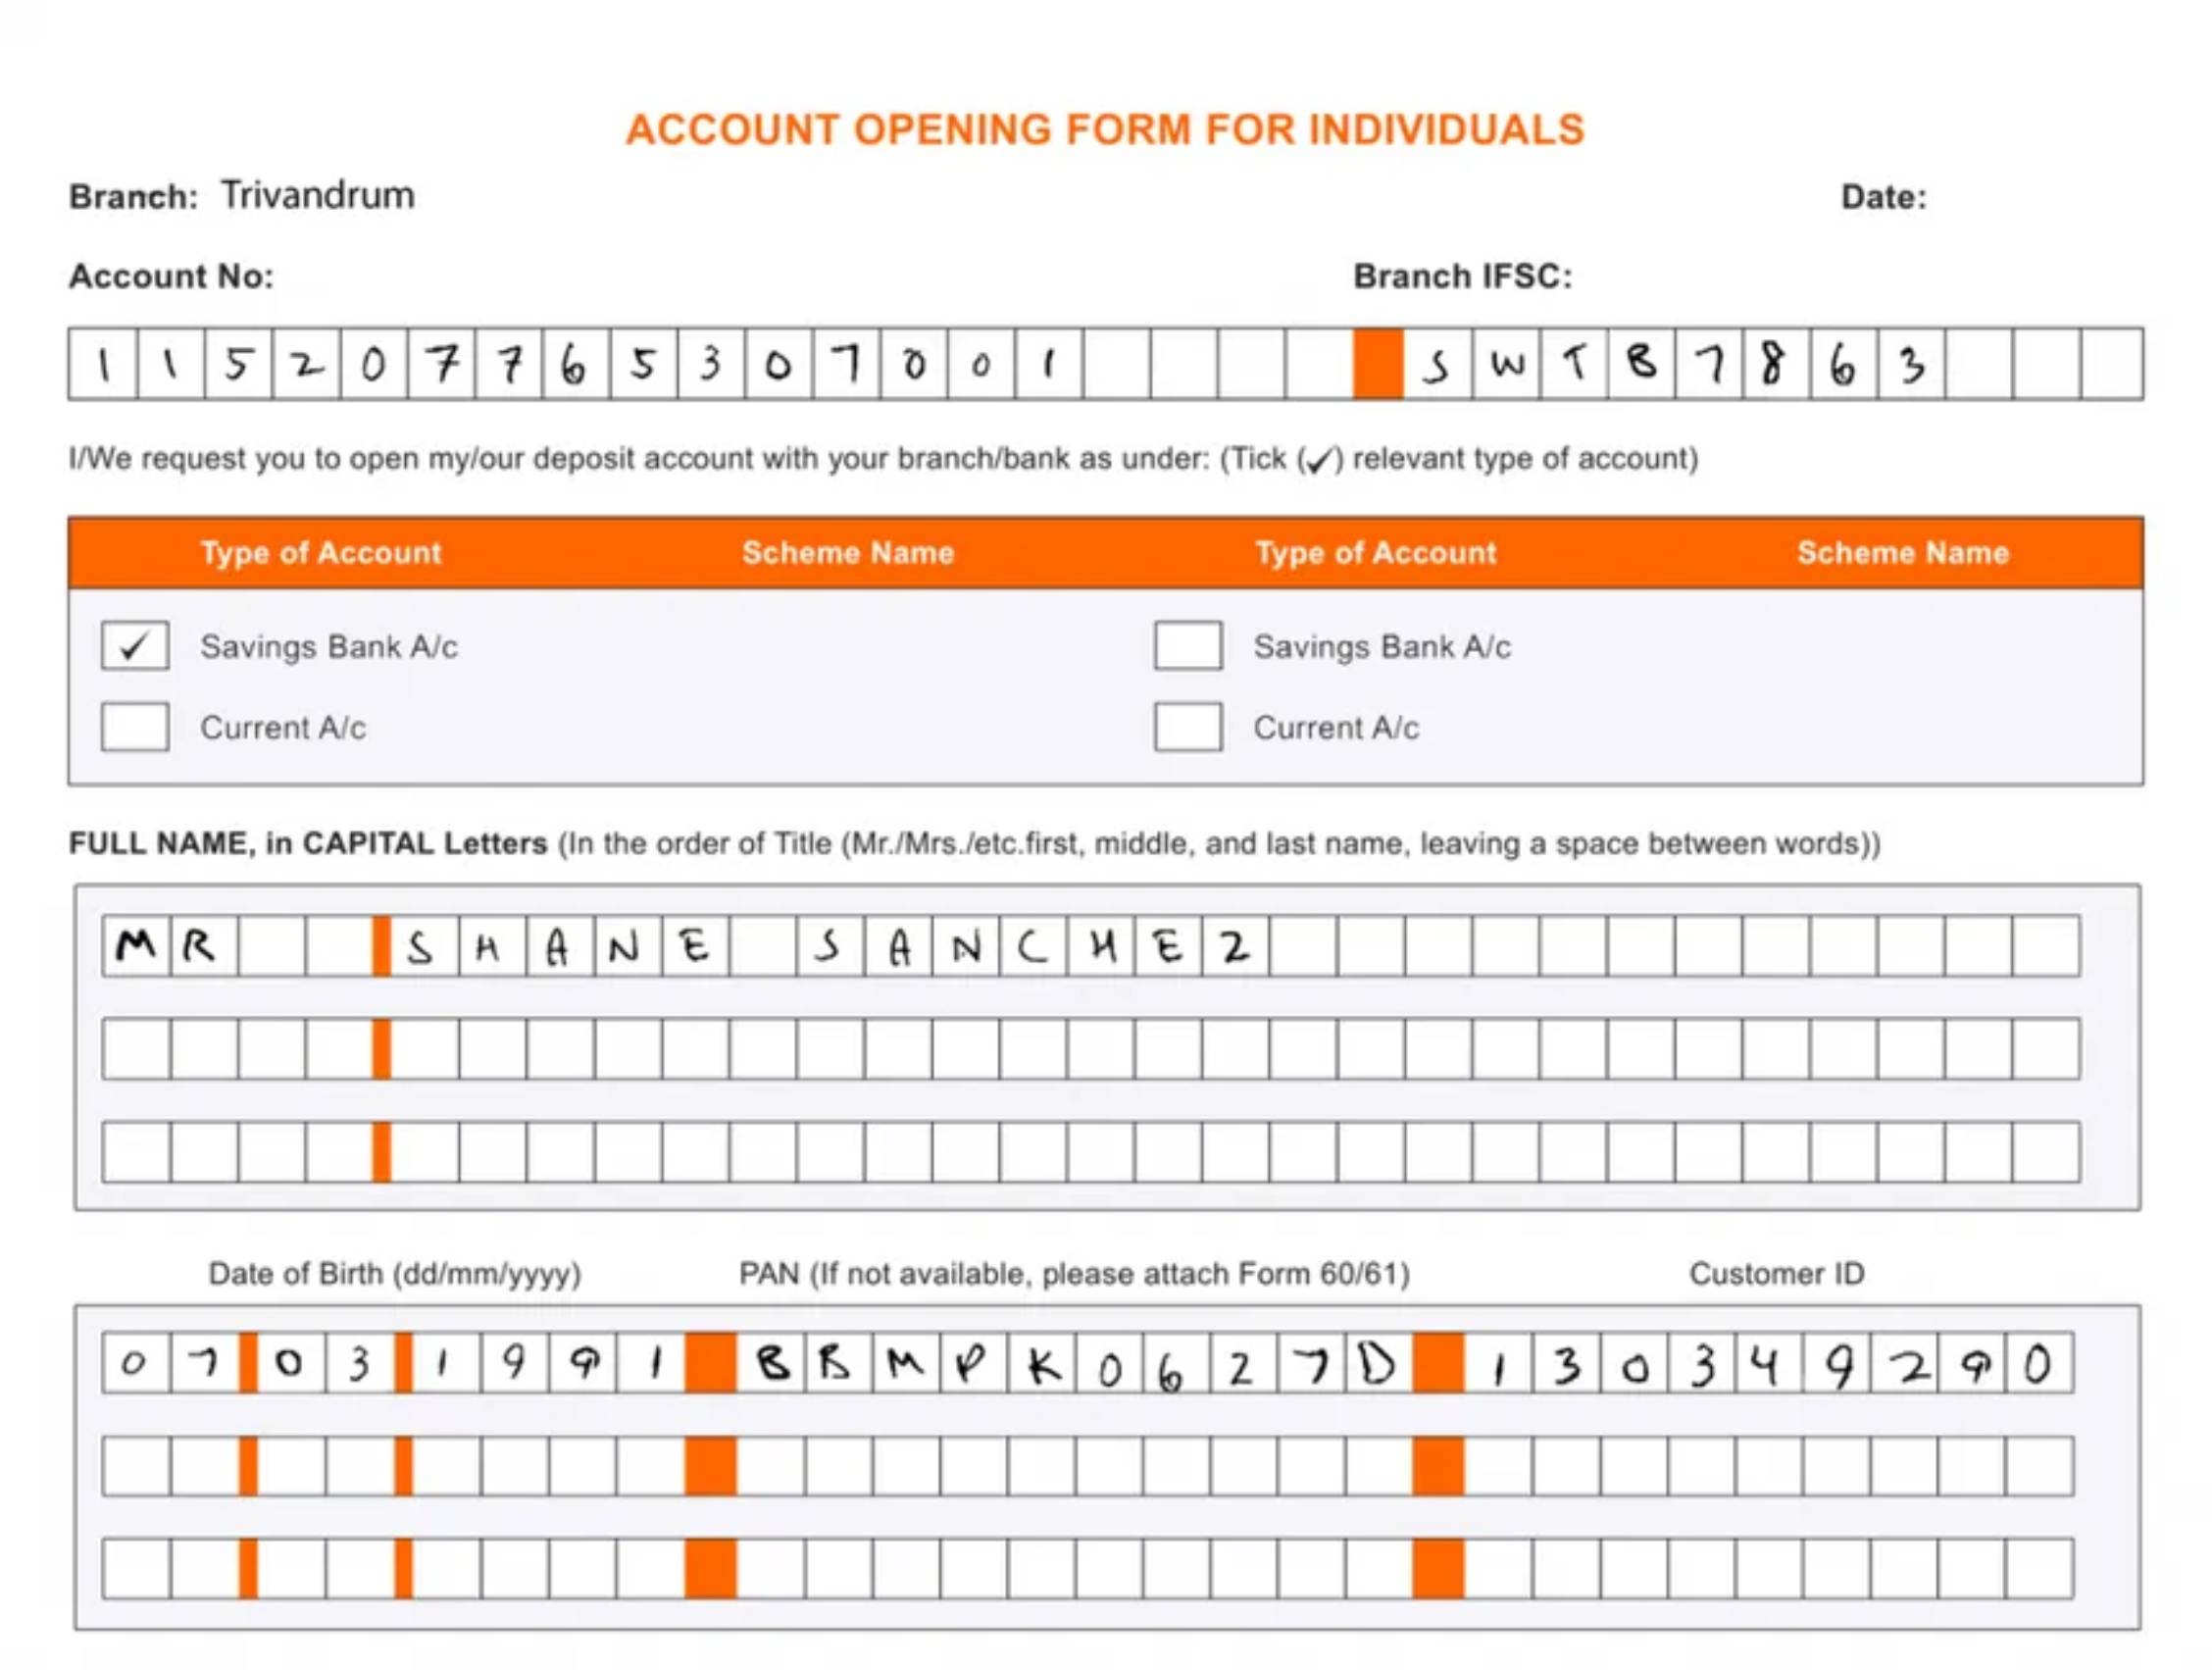

In [ ]:
# file info
image_url = "https://raw.githubusercontent.com/aaronhowellai/machine-learning-projects/main/resources/handwritten%20form.jpg"
filename = "handwritten form.jpg"

display_image(image_url, filename)

In [ ]:
# for desktop version, use: "get_base64_encoded_image(desktop_path)}},"

In [ ]:
# this is the colab version
message_list = [
    {
        "role":"user",
        "content": [
            {"type": "image", "source": {"type": "base64", "media_type":"image/jpeg", "data": get_base64_encoded_image(image_path="/content/handwritten form.jpg")}},
            {"type": "text", "text": "Transcribe this text. Output text only and use formatting such as '- bullet point' or '-------- (separator)' if necessary."}
        ]
    }
]

response = client.messages.create(
    model=MODEL_ID,
    max_tokens=3000,
    messages = message_list
)

response_text = response.content[0].text
display(Markdown(f"""\
{response_text}
"""))

ACCOUNT OPENING FORM FOR INDIVIDUALS

Branch: Trivandrum                                                           Date:

Account No:                                                     Branch IFSC:

11520776530700[    ]SW1B7863[    ]

I/We request you to open my/our deposit account with your branch/bank as under: (Tick (✓) relevant type of account)

Type of Account          Scheme Name          Type of Account          Scheme Name

✓ Savings Bank A/c                            □ Savings Bank A/c
□ Current A/c                                 □ Current A/c

FULL NAME, in CAPITAL Letters (In the order of Title (Mr./Mrs./etc.first, middle, and last name, leaving a space between words))

MR SAANE SANCHEZ

Date of Birth (dd/mm/yyyy)          PAN (If not available, please attach Form 60/61)          Customer ID

07/03/1991                         EGMKK0627D                                      130349290


## **Conditional Transcription From a Technical Document**
* **Example Used:** Recent reasoning research: GRPO tweaks, base model RL, and data curation
  * [GitHub Posted Link](https://raw.githubusercontent.com/aaronhowellai/machine-learning-projects/main/resources/grpo%20research.jpg)
  * [Actual Web Link](https://www.google.com/url?sa=i&url=https%3A%2F%2Fwww.interconnects.ai%2Fp%2Fpapers-im-reading-base-model-rl-grpo&psig=AOvVaw2RBBPS-yARtzq6Ci4lCoyU&ust=1754347202035000&source=images&cd=vfe&opi=89978449&ved=0CBkQjhxqFwoTCOCevbTb744DFQAAAAAdAAAAABAE)

Image already downloaded locally.


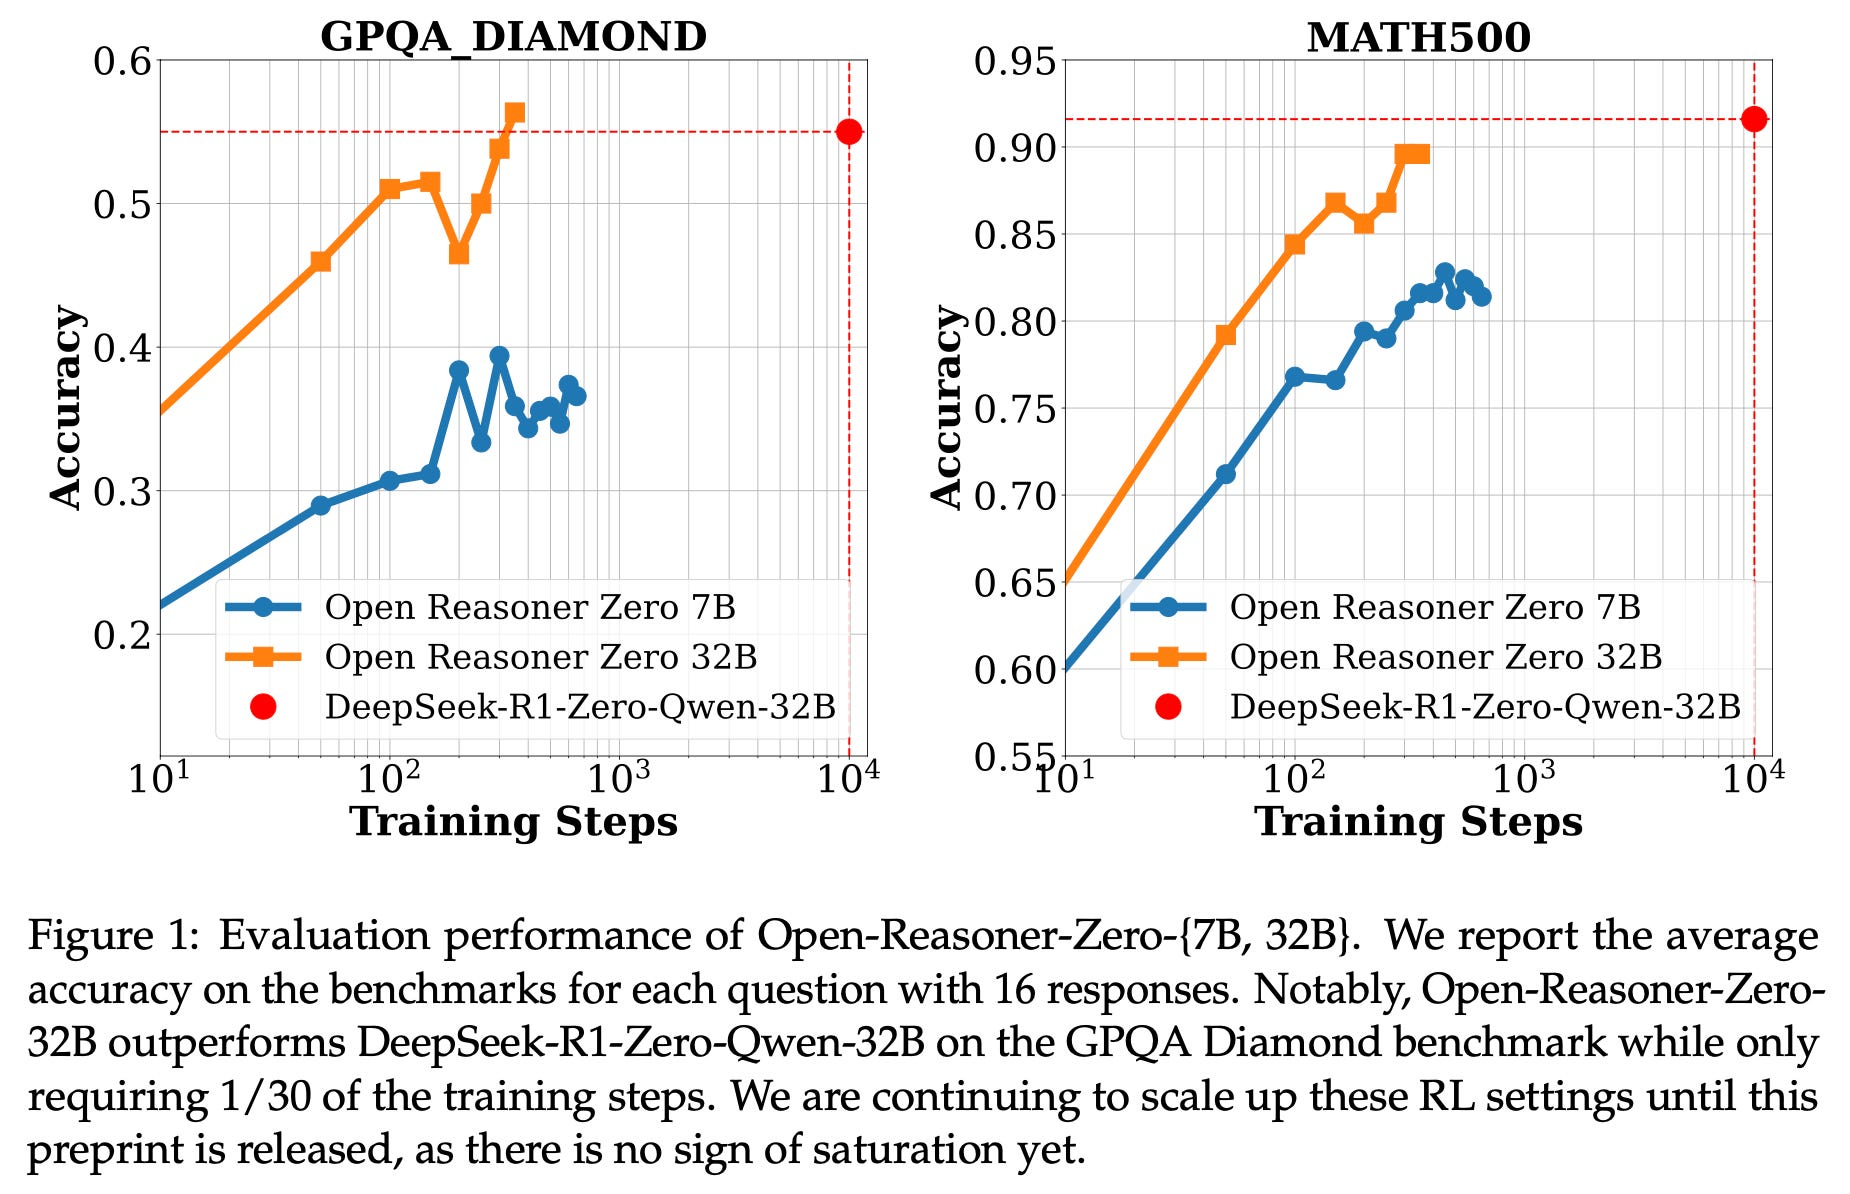

In [ ]:
# file info
image_url = "https://raw.githubusercontent.com/aaronhowellai/machine-learning-projects/main/resources/grpo%20research.jpg"
filename = "grpo research.jpg"

display_image(image_url, filename)

In [ ]:
# for desktop version, use: "get_base64_encoded_image(desktop_path)}},"

In [ ]:
# this is the colab version
message_list = [
    {
        "role":"user",
        "content": [
            {"type": "image", "source": {"type": "base64", "media_type":"image/jpeg", "data": get_base64_encoded_image(image_path="/content/grpo research.jpg")}},
            {"type": "text", "text": "Summarise what this image is trying to communicate from the context given."}
        ]
    }
]

response = client.messages.create(
    model=MODEL_ID,
    max_tokens=3000,
    messages = message_list
)

response_text = response.content[0].text
display(Markdown(f"""\
{response_text}
"""))

This image presents performance comparisons between different AI reasoning models on two mathematical benchmarks (GPOA_DIAMOND and MATH500). The key findings are:

1. **Model Comparison**: The graphs compare three models - Open Reasoner Zero 7B (blue), Open Reasoner Zero 32B (orange), and DeepSeek-R1-Zero-Qwen-32B (red dot).

2. **Training Efficiency**: The most striking finding is that Open-Reasoner-Zero-32B achieves comparable or better performance than DeepSeek-R1-Zero-Qwen-32B while using only 1/30th of the training steps (noted in the caption).

3. **Performance Trends**: Both Open Reasoner models show steady improvement with more training steps on a logarithmic scale, with the 32B model consistently outperforming the 7B version.

4. **No Saturation**: The caption emphasizes that performance hasn't plateaued yet, suggesting potential for further improvements with continued training.

5. **Benchmark Results**: 
   - On GPOA_DIAMOND: Open-Reasoner-Zero-32B slightly outperforms DeepSeek
   - On MATH500: Performance is very close between the two 32B models

The image effectively demonstrates that the Open Reasoner models achieve competitive performance with significantly greater training efficiency compared to existing approaches.


## **Unstructured Information to Structured JSON and YAML Format**
* **Example Used:** FAANG Individual Contributor Compensation Levels
  * [GitHub Posted Link](https://raw.githubusercontent.com/aaronhowellai/machine-learning-projects/main/resources/faang%20ic%20levels.jpg)
  * [Actual Web Link](https://engineeringbolt.com/tech/google-software-engineer-levels-roles-expectations-salary/)

Image already downloaded locally.


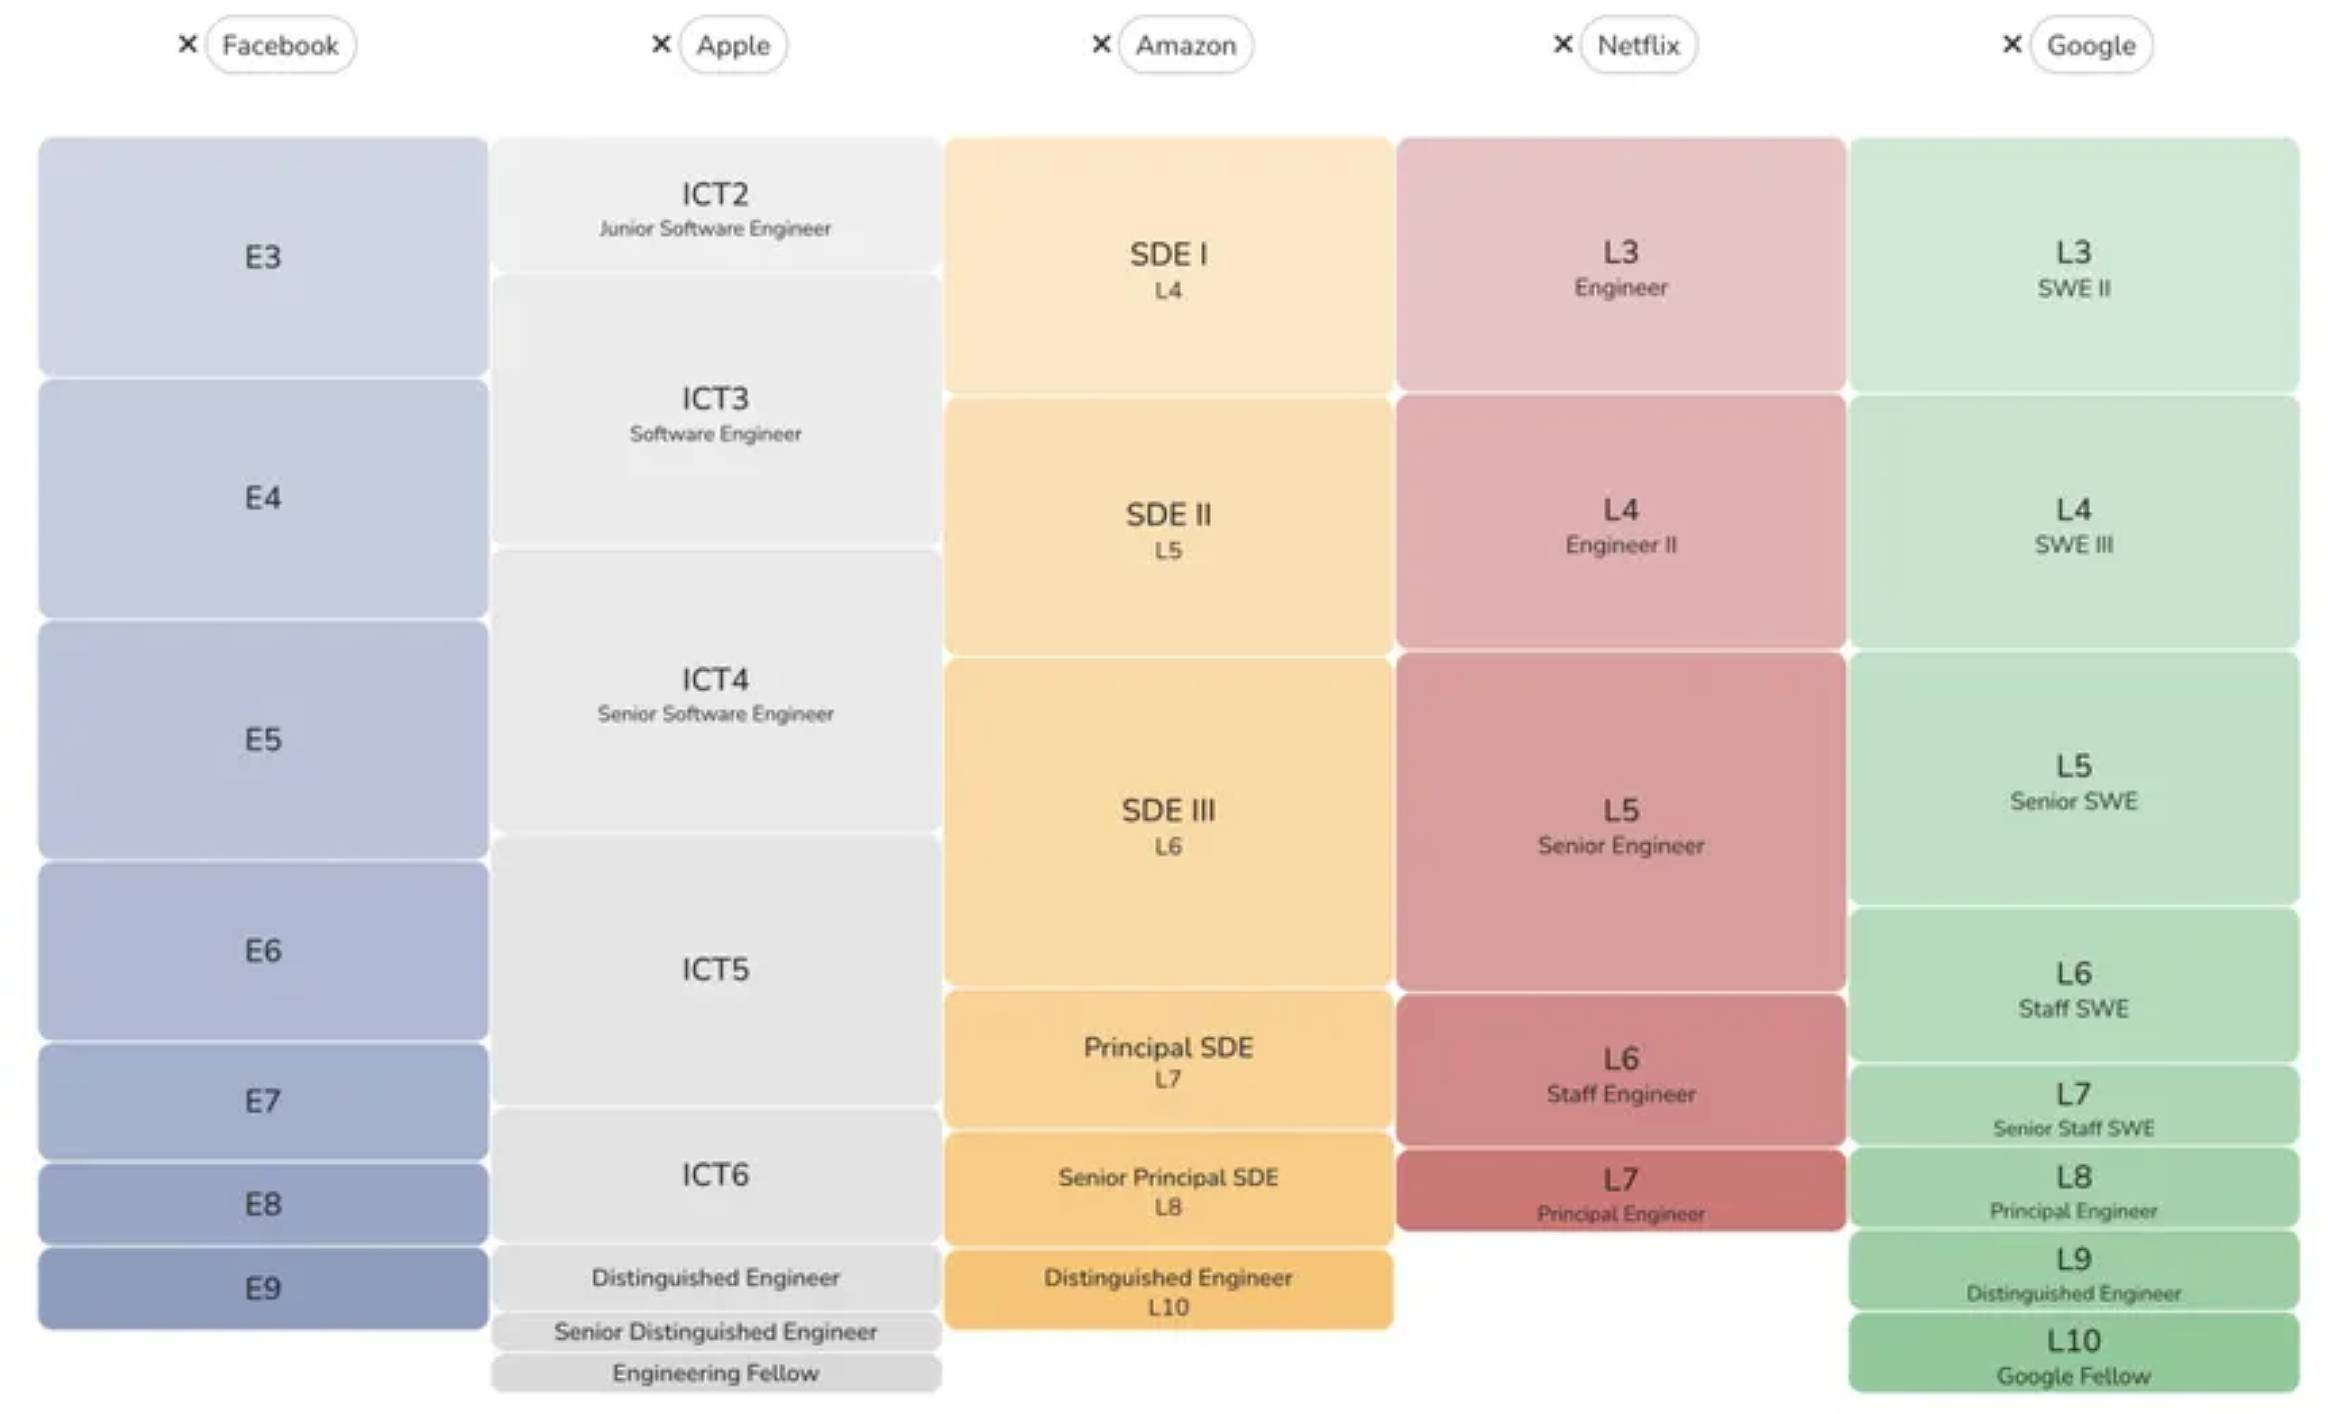

In [ ]:
# file info
image_url = "https://raw.githubusercontent.com/aaronhowellai/machine-learning-projects/main/resources/faang%20ic%20levels.jpg"
filename = "faang ic levels.jpg"
local_path = None

display_image(image_url, filename)

In [ ]:
# for desktop version, use: "get_base64_encoded_image(desktop_path)}},"

In [ ]:
# this is the colab version for the yaml output
message_list = [
    {
        "role":"user",
        "content": [
            {"type": "image", "source": {"type": "base64", "media_type":"image/jpeg", "data": get_base64_encoded_image(image_path="/content/faang ic levels.jpg")}},
            {"type": "text", "text": "Turn this faang ic levels comparison chart into a YAML output, in the most appropriate format you deem worthy of the content structure in the image."}
        ]
    }
]

response = client.messages.create(
    model=MODEL_ID,
    max_tokens=3000,
    messages = message_list
)

print(response.content[0].text)

```yaml
faang_engineering_levels:
  facebook:
    E3:
      - ICT2
      - Junior Software Engineer
    E4:
      - ICT3
      - Software Engineer
    E5:
      - ICT4
      - Senior Software Engineer
    E6:
      - ICT5
    E7:
      - ICT6
    E8:
      - ICT6
    E9:
      - Distinguished Engineer
      - Senior Distinguished Engineer
      - Engineering Fellow

  apple:
    L4:
      - SDE I
    L5:
      - SDE II
    L6:
      - SDE III
    L7:
      - Principal SDE
    L8:
      - Senior Principal SDE
    L10:
      - Distinguished Engineer

  amazon:
    L4:
      - SDE I
    L5:
      - SDE II
    L6:
      - SDE III
    L7:
      - Principal SDE
    L8:
      - Senior Principal SDE
    L10:
      - Distinguished Engineer

  netflix:
    L3:
      - Engineer
    L4:
      - Engineer II
    L5:
      - Senior Engineer
    L6:
      - Staff Engineer
    L7:
      - Principal Engineer

  google:
    L3:
      - SWE II
    L4:
      - SWE III
    L5:
      - Senior SWE
    L6:
   

In [ ]:
# this is the colab version for the JSON output
message_list = [
    {
        "role":"user",
        "content": [
            {"type": "image", "source": {"type": "base64", "media_type":"image/jpeg", "data": get_base64_encoded_image(image_path="/content/faang ic levels.jpg")}},
            {"type": "text", "text": "Turn this faang ic levels comparison chart into a JSON output, in the most appropriate format you deem worthy of the content structure in the image."}
        ]
    }
]

response = client.messages.create(
    model=MODEL_ID,
    max_tokens=3000,
    messages = message_list
)

print(response.content[0].text)

```json
{
  "engineering_levels_comparison": {
    "companies": ["Facebook", "Apple", "Amazon", "Netflix", "Google"],
    "levels": {
      "E3": {
        "Facebook": {
          "titles": ["ICT2", "Junior Software Engineer"]
        },
        "Apple": {
          "titles": ["ICT2", "Junior Software Engineer"]
        },
        "Amazon": {
          "titles": ["SDE I"],
          "level": "L4"
        },
        "Netflix": {
          "titles": ["L3", "Engineer"]
        },
        "Google": {
          "titles": ["L3", "SWE II"]
        }
      },
      "E4": {
        "Facebook": {
          "titles": ["ICT3", "Software Engineer"]
        },
        "Apple": {
          "titles": ["ICT3", "Software Engineer"]
        },
        "Amazon": {
          "titles": ["SDE II"],
          "level": "L5"
        },
        "Netflix": {
          "titles": ["L4", "Engineer II"]
        },
        "Google": {
          "titles": ["L4", "SWE III"]
        }
      },
      "E5": {
        "Face